# Modelling

This notebook develops and evaluates models for the next-category recommendation task.

The processed dataset contains one row per historical prediction opportunity, with household, customer, property, AI-derived and video-derived information available at that moment.

> **Hypothesis test: anonymisation cost (classification).** Release: `source_dataset` (source release). Feature set: `03_pure_record` (12 predictors). Modelling code is unchanged from the official `03_fm_modelling.ipynb` except for: (1) data, split and output paths; (2) the split is grouped by `Customer_ID` and stored in a shared `split_assignment.csv` so that every release and feature set uses the same partitions; (3) the feature-set definition; (4) saving of results and models; (5) the built-in AI-ablation section is removed.

Train, validation and test partitions are created by `Customer_ID` so that all properties of one customer, and therefore all historical states of the same household, stay in a single partition.

In [3]:
# -------------------------------------------------------------------
# Imports And Data Loading
# -------------------------------------------------------------------

from pathlib import Path

import pandas as pd

DATASET = "source_dataset"
FEATURE_SET = "03_pure_record"
MODEL_PREFIX = "source_pure_record"

DATA_PATH = Path("../../../../data/processed/hypothesis_testing/source_dataset/model_state.csv")
SPLIT_PATH = Path("../../../../data/processed/hypothesis_testing/split_assignment.csv")
OUTPUT_DIR = Path("../../../../data/processed/hypothesis_testing/source_dataset/03_pure_record")
MODELS_DIR = Path("../../../../models/hypothesis_testing")

model_state = pd.read_csv(
    DATA_PATH,
    parse_dates=["Prediction_Time"],
)

print("MODELLING DATASET LOADED")
print("-" * 60)

print(f"Rows:       {len(model_state):,}")
print(f"Properties: {model_state['Property_ID'].nunique():,}")
print(f"Customers:  {model_state['Customer_ID'].nunique():,}")
print(f"Columns:    {model_state.shape[1]:,}")

MODELLING DATASET LOADED
------------------------------------------------------------
Rows:       431
Properties: 234
Customers:  198
Columns:    60


## Grouped Train Validation Test Split

The modelling dataset is partitioned by customer rather than by individual rows.

A customer can own several properties. Grouping by `Customer_ID` keeps every historical prediction state of every property of that customer within a single partition, preventing information from the same household or the same customer from leaking across training, validation and final test sets.

The partition of every `Property_ID` is saved to `split_assignment.csv` the first time the split is created. Later runs (other feature sets and the other release) load that file, so all experiment cells are evaluated on exactly the same partitions.

In [4]:
# -------------------------------------------------------------------
# Grouped Train / Validation / Test Split
# -------------------------------------------------------------------

import numpy as np
from sklearn.model_selection import GroupShuffleSplit

# Separate predictors, target and grouping variable.
X = model_state.drop(
    columns=[
        "Next_Category_ID",
        "Next_Category",
    ]
).copy()

y = model_state["Next_Category"].copy()
groups = model_state["Customer_ID"].copy()

if SPLIT_PATH.exists():

    # -----------------------------------------------------------
    # Reuse the shared partition assignment
    # -----------------------------------------------------------

    split_assignment = pd.read_csv(SPLIT_PATH)

    partition_map = split_assignment.set_index("Property_ID")["Partition"]

    unassigned = set(X["Property_ID"]) - set(partition_map.index)

    if unassigned:
        raise ValueError(
            f"{len(unassigned)} properties have no partition in {SPLIT_PATH}"
        )

    partition = X["Property_ID"].map(partition_map).to_numpy()

    train_idx = np.flatnonzero(partition == "train")
    val_idx = np.flatnonzero(partition == "validation")
    test_idx = np.flatnonzero(partition == "test")

    print(f"Split loaded from: {SPLIT_PATH}")

else:

    # -----------------------------------------------------------
    # First split:
    # 70% Train
    # 30% Temporary
    # -----------------------------------------------------------

    train_splitter = GroupShuffleSplit(
        n_splits=1,
        train_size=0.70,
        random_state=42,
    )

    train_idx, temp_idx = next(
        train_splitter.split(
            X,
            y,
            groups=groups,
        )
    )

    X_temp = X.iloc[temp_idx].copy()
    y_temp = y.iloc[temp_idx].copy()

    temp_groups = groups.iloc[temp_idx].copy()

    # -----------------------------------------------------------
    # Second split:
    # Temporary -> 50% Validation / 50% Test
    #
    # Final proportions:
    # Train      ~70%
    # Validation ~15%
    # Test       ~15%
    # -----------------------------------------------------------

    validation_splitter = GroupShuffleSplit(
        n_splits=1,
        train_size=0.50,
        random_state=42,
    )

    val_rel_idx, test_rel_idx = next(
        validation_splitter.split(
            X_temp,
            y_temp,
            groups=temp_groups,
        )
    )

    val_idx = temp_idx[val_rel_idx]
    test_idx = temp_idx[test_rel_idx]

    # -----------------------------------------------------------
    # Save the shared partition assignment
    # -----------------------------------------------------------

    split_assignment = pd.concat(
        [
            X.iloc[idx][["Property_ID", "Customer_ID"]].assign(Partition=name)
            for name, idx in [
                ("train", train_idx),
                ("validation", val_idx),
                ("test", test_idx),
            ]
        ]
    ).drop_duplicates(subset="Property_ID")

    SPLIT_PATH.parent.mkdir(parents=True, exist_ok=True)
    split_assignment.to_csv(SPLIT_PATH, index=False)

    print(f"Split created and saved to: {SPLIT_PATH}")

X_train = X.iloc[train_idx].copy()
y_train = y.iloc[train_idx].copy()

X_val = X.iloc[val_idx].copy()
y_val = y.iloc[val_idx].copy()

X_test = X.iloc[test_idx].copy()
y_test = y.iloc[test_idx].copy()

# ---------------------------------------------------------------
# Leakage check
# ---------------------------------------------------------------

train_properties = set(X_train["Property_ID"])
val_properties = set(X_val["Property_ID"])
test_properties = set(X_test["Property_ID"])

train_customers = set(X_train["Customer_ID"])
val_customers = set(X_val["Customer_ID"])
test_customers = set(X_test["Customer_ID"])

print()
print("GROUPED DATA SPLIT (BY CUSTOMER)")
print("-" * 60)

print(
    f"Train:      {len(X_train):>3} rows | "
    f"{X_train['Property_ID'].nunique():>3} properties | "
    f"{X_train['Customer_ID'].nunique():>3} customers"
)

print(
    f"Validation: {len(X_val):>3} rows | "
    f"{X_val['Property_ID'].nunique():>3} properties | "
    f"{X_val['Customer_ID'].nunique():>3} customers"
)

print(
    f"Test:       {len(X_test):>3} rows | "
    f"{X_test['Property_ID'].nunique():>3} properties | "
    f"{X_test['Customer_ID'].nunique():>3} customers"
)

print()

print(
    "Customer overlap  (Train/Val, Train/Test, Val/Test):",
    len(train_customers & val_customers),
    len(train_customers & test_customers),
    len(val_customers & test_customers),
)

print(
    "Property overlap  (Train/Val, Train/Test, Val/Test):",
    len(train_properties & val_properties),
    len(train_properties & test_properties),
    len(val_properties & test_properties),
)


Split loaded from: ..\..\..\..\data\processed\hypothesis_testing\split_assignment.csv

GROUPED DATA SPLIT (BY CUSTOMER)
------------------------------------------------------------
Train:      315 rows | 166 properties | 138 customers
Validation:  57 rows |  33 properties |  30 customers
Test:        59 rows |  35 properties |  30 customers

Customer overlap  (Train/Val, Train/Test, Val/Test): 0 0 0
Property overlap  (Train/Val, Train/Test, Val/Test): 0 0 0


### Split Leakage Audit

The chosen customer-grouped split is compared with the property-grouped split used by the official notebook (same seed, same procedure).

For each design the number of customers whose rows fall in more than one partition is counted. This quantifies the cross-partition customer leakage that the customer-grouped split removes. The audit uses no model and is shown for documentation only.

In [5]:
# -------------------------------------------------------------------
# Split Leakage Audit
# -------------------------------------------------------------------

# Reproduce the property-grouped split of the official notebook.
property_groups = model_state["Property_ID"].copy()

audit_train_idx, audit_temp_idx = next(
    GroupShuffleSplit(
        n_splits=1,
        train_size=0.70,
        random_state=42,
    ).split(
        X,
        y,
        groups=property_groups,
    )
)

audit_val_rel_idx, audit_test_rel_idx = next(
    GroupShuffleSplit(
        n_splits=1,
        train_size=0.50,
        random_state=42,
    ).split(
        X.iloc[audit_temp_idx],
        y.iloc[audit_temp_idx],
        groups=property_groups.iloc[audit_temp_idx],
    )
)

property_split_partition = pd.Series("train", index=X.index)
property_split_partition.iloc[audit_temp_idx[audit_val_rel_idx]] = "validation"
property_split_partition.iloc[audit_temp_idx[audit_test_rel_idx]] = "test"

customer_split_partition = pd.Series("train", index=X.index)
customer_split_partition.iloc[val_idx] = "validation"
customer_split_partition.iloc[test_idx] = "test"


def customers_spanning_partitions(partition_series):
    """Return the customers present in more than one partition."""
    spread = (
        pd.DataFrame(
            {
                "Customer_ID": X["Customer_ID"],
                "Partition": partition_series,
            }
        )
        .groupby("Customer_ID")["Partition"]
        .nunique()
    )
    return spread[spread > 1].index


audit_rows = []

for design, partition_series in {
    "Grouped by Property_ID (official notebook)": property_split_partition,
    "Grouped by Customer_ID (this experiment)": customer_split_partition,
}.items():

    spanning = customers_spanning_partitions(partition_series)

    audit_rows.append(
        {
            "Split design": design,
            "Customers in 2+ partitions": len(spanning),
            "Rows of those customers": int(X["Customer_ID"].isin(spanning).sum()),
        }
    )

print("SPLIT LEAKAGE AUDIT")
print("-" * 80)

print(pd.DataFrame(audit_rows).to_string(index=False))

SPLIT LEAKAGE AUDIT
--------------------------------------------------------------------------------
                              Split design  Customers in 2+ partitions  Rows of those customers
Grouped by Property_ID (official notebook)                          18                       82
  Grouped by Customer_ID (this experiment)                           0                        0


## Feature Set Definition

This run uses the **pure-record feature set** (`03_pure_record`): only the 12 predictors that describe the already documented inventory are retained (the documented category profile, 7 counts, and the documented aggregates, 5 values). The AI-derived, property-context, customer-profile, customer-attribute and video predictors (43 columns) are removed.

None of the retained predictors differs between the source and the anonymised release, so the two releases are expected to give the same results for this feature set. The built-in AI-ablation section of the official notebook is not included because the AI features are already removed.

In [6]:
# -------------------------------------------------------------------
# Feature Set Definition
# -------------------------------------------------------------------

# Pure-record feature set: only the documented-inventory predictors.
RECORD_FEATURES = [
    "documented_asset_count",
    "documented_category_count",
    "documented_value_total",
    "documented_replacement_cost_total",
    "mean_evidence_rating",
    "documented_count_CAT-001",
    "documented_count_CAT-002",
    "documented_count_CAT-003",
    "documented_count_CAT-004",
    "documented_count_CAT-005",
    "documented_count_CAT-006",
    "documented_count_CAT-007",
]

missing_record_features = [
    column
    for column in RECORD_FEATURES
    if column not in X.columns
]

assert not missing_record_features, missing_record_features

# Everything else except the identifiers and the timestamp is removed.
DROPPED_FEATURES = [
    column
    for column in X.columns
    if column not in RECORD_FEATURES
    and column not in ["Property_ID", "Customer_ID", "Prediction_Time"]
]

# Number of predictors expected after identifiers and the timestamp are excluded.
EXPECTED_PREDICTOR_COUNT = 12

assert len(DROPPED_FEATURES) == 43, (
    f"Expected 43 removed predictors, found {len(DROPPED_FEATURES)}"
)

print("FEATURE SET")
print("-" * 60)

print(f"Feature set:        {FEATURE_SET}")
print(f"Kept predictors:    {len(RECORD_FEATURES)}")
print(f"Dropped predictors: {len(DROPPED_FEATURES)}")

FEATURE SET
------------------------------------------------------------
Feature set:        03_pure_record
Kept predictors:    12
Dropped predictors: 43


## Majority Class Baseline

A simple majority-class classifier is used as the initial benchmark.

This baseline always predicts the most frequent next category observed in the training data. More advanced models must provide measurable improvement over this reference while the final test set remains untouched.

In [7]:
# -------------------------------------------------------------------
# Majority Class Baseline
# -------------------------------------------------------------------

from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score

# The baseline does not learn from the predictors.
# It simply predicts the most frequent class observed in training.
baseline_model = DummyClassifier(
    strategy="most_frequent",
)

baseline_model.fit(
    X_train,
    y_train,
)

# Evaluate only on the validation set.
baseline_predictions = baseline_model.predict(X_val)

baseline_accuracy = accuracy_score(
    y_val,
    baseline_predictions,
)

baseline_macro_f1 = f1_score(
    y_val,
    baseline_predictions,
    average="macro",
    zero_division=0,
)

baseline_weighted_f1 = f1_score(
    y_val,
    baseline_predictions,
    average="weighted",
    zero_division=0,
)

print("MAJORITY CLASS BASELINE")
print("-" * 60)

print(
    f"Most frequent training class: "
    f"{baseline_model.classes_[baseline_model.class_prior_.argmax()]}"
)

print()
print(f"Validation Accuracy:    {baseline_accuracy:.4f}")
print(f"Validation Macro F1:    {baseline_macro_f1:.4f}")
print(f"Validation Weighted F1: {baseline_weighted_f1:.4f}")

MAJORITY CLASS BASELINE
------------------------------------------------------------
Most frequent training class: Other Items

Validation Accuracy:    0.2281
Validation Macro F1:    0.0619
Validation Weighted F1: 0.0847


## Logistic Regression Baseline

A multinomial Logistic Regression model is used as the first learned benchmark.

Categorical encoding, missing-value imputation and numerical scaling are fitted exclusively on the training partition through a scikit-learn pipeline. Property and customer identifiers, together with the prediction timestamp, are excluded from the predictors to avoid memorisation of household identities or arbitrary temporal identifiers.

In [8]:
# -------------------------------------------------------------------
# Logistic Regression Baseline
# -------------------------------------------------------------------

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    top_k_accuracy_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# ---------------------------------------------------------------
# Remove identifiers and timestamp from the model predictors.
# Customer_ID and Property_ID are retained in the data for grouping,
# but they should not be learned as predictive features.
# ---------------------------------------------------------------

excluded_features = [
    "Property_ID",
    "Customer_ID",
    "Prediction_Time",
] + DROPPED_FEATURES

X_train_model = X_train.drop(
    columns=excluded_features,
    errors="ignore",
).copy()

X_val_model = X_val.drop(
    columns=excluded_features,
    errors="ignore",
).copy()

assert X_train_model.shape[1] == EXPECTED_PREDICTOR_COUNT, (
    f"Expected {EXPECTED_PREDICTOR_COUNT} predictors, "
    f"found {X_train_model.shape[1]}"
)

print(f"Predictors used: {X_train_model.shape[1]}")

# ---------------------------------------------------------------
# Identify numerical and categorical predictors.
# ---------------------------------------------------------------

categorical_features = (
    X_train_model
    .select_dtypes(include=["object", "bool"])
    .columns
    .tolist()
)

numerical_features = (
    X_train_model
    .select_dtypes(include=["number"])
    .columns
    .tolist()
)

# ---------------------------------------------------------------
# Preprocessing
# ---------------------------------------------------------------

numerical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median"),
        ),
        (
            "scaler",
            StandardScaler(),
        ),
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent"),
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
            ),
        ),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            numerical_pipeline,
            numerical_features,
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features,
        ),
    ]
)

# ---------------------------------------------------------------
# Model
# ---------------------------------------------------------------

logistic_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor,
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=5000,
                random_state=42,
            ),
        ),
    ]
)

logistic_model.fit(
    X_train_model,
    y_train,
)

# ---------------------------------------------------------------
# Validation predictions
# ---------------------------------------------------------------

logistic_predictions = logistic_model.predict(
    X_val_model
)

logistic_probabilities = logistic_model.predict_proba(
    X_val_model
)

classes = logistic_model.named_steps[
    "classifier"
].classes_

# ---------------------------------------------------------------
# Metrics
# ---------------------------------------------------------------

logistic_accuracy = accuracy_score(
    y_val,
    logistic_predictions,
)

logistic_macro_f1 = f1_score(
    y_val,
    logistic_predictions,
    average="macro",
    zero_division=0,
)

logistic_weighted_f1 = f1_score(
    y_val,
    logistic_predictions,
    average="weighted",
    zero_division=0,
)

logistic_top2 = top_k_accuracy_score(
    y_val,
    logistic_probabilities,
    k=2,
    labels=classes,
)

logistic_top3 = top_k_accuracy_score(
    y_val,
    logistic_probabilities,
    k=3,
    labels=classes,
)

print("LOGISTIC REGRESSION BASELINE")
print("-" * 60)

print(f"Validation Accuracy:    {logistic_accuracy:.4f}")
print(f"Validation Macro F1:    {logistic_macro_f1:.4f}")
print(f"Validation Weighted F1: {logistic_weighted_f1:.4f}")
print(f"Validation Top-2 Acc:   {logistic_top2:.4f}")
print(f"Validation Top-3 Acc:   {logistic_top3:.4f}")

Predictors used: 12
LOGISTIC REGRESSION BASELINE
------------------------------------------------------------
Validation Accuracy:    0.3509
Validation Macro F1:    0.2628
Validation Weighted F1: 0.2934
Validation Top-2 Acc:   0.6491
Validation Top-3 Acc:   0.8421


## Random Forest Model

A Random Forest classifier is evaluated as a non-linear alternative to Logistic Regression.

The model can capture interactions between household composition, AI-derived signals and customer or property context. Class weighting is applied to reduce the dominance of the more frequent target categories.

In [9]:
# -------------------------------------------------------------------
# Random Forest Model
# -------------------------------------------------------------------

from sklearn.ensemble import RandomForestClassifier

# Reuse the same preprocessing structure to ensure a fair comparison.
random_forest_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor,
        ),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=500,
                class_weight="balanced_subsample",
                random_state=42,
                n_jobs=-1,
            ),
        ),
    ]
)

# Train only on the training partition.
random_forest_model.fit(
    X_train_model,
    y_train,
)

# Validation predictions.
rf_predictions = random_forest_model.predict(
    X_val_model
)

rf_probabilities = random_forest_model.predict_proba(
    X_val_model
)

rf_classes = random_forest_model.named_steps[
    "classifier"
].classes_

# Evaluation metrics.
rf_accuracy = accuracy_score(
    y_val,
    rf_predictions,
)

rf_macro_f1 = f1_score(
    y_val,
    rf_predictions,
    average="macro",
    zero_division=0,
)

rf_weighted_f1 = f1_score(
    y_val,
    rf_predictions,
    average="weighted",
    zero_division=0,
)

rf_top2 = top_k_accuracy_score(
    y_val,
    rf_probabilities,
    k=2,
    labels=rf_classes,
)

rf_top3 = top_k_accuracy_score(
    y_val,
    rf_probabilities,
    k=3,
    labels=rf_classes,
)

print("RANDOM FOREST")
print("-" * 60)

print(f"Validation Accuracy:    {rf_accuracy:.4f}")
print(f"Validation Macro F1:    {rf_macro_f1:.4f}")
print(f"Validation Weighted F1: {rf_weighted_f1:.4f}")
print(f"Validation Top-2 Acc:   {rf_top2:.4f}")
print(f"Validation Top-3 Acc:   {rf_top3:.4f}")

RANDOM FOREST
------------------------------------------------------------
Validation Accuracy:    0.3860
Validation Macro F1:    0.3130
Validation Weighted F1: 0.3709
Validation Top-2 Acc:   0.6842
Validation Top-3 Acc:   0.8421


## Tuned CatBoost Model

CatBoost is evaluated as a stronger non-linear model for the next-category recommendation task.

Hyperparameters are tuned using grouped cross-validation so that historical states from the same customer (and therefore the same property) remain within the same fold. Macro F1 is used as the primary optimisation metric to account for the imbalanced multiclass target.

In [10]:
# -------------------------------------------------------------------
# Tuned CatBoost Model
# -------------------------------------------------------------------

from catboost import CatBoostClassifier
from sklearn.model_selection import GroupKFold, RandomizedSearchCV

# ---------------------------------------------------------------
# CatBoost works well with encoded tabular data, so we reuse the
# existing preprocessing pipeline for a fair comparison.
# ---------------------------------------------------------------

catboost_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor,
        ),
        (
            "classifier",
            CatBoostClassifier(
                loss_function="MultiClass",
                verbose=0,
                random_seed=42,
                auto_class_weights="Balanced",
                thread_count=-1,
            ),
        ),
    ]
)

# ---------------------------------------------------------------
# Search space
# ---------------------------------------------------------------

catboost_param_grid = {
    "classifier__iterations": [
        300,
        500,
        800,
        1200,
    ],
    "classifier__depth": [
        4,
        5,
        6,
        7,
        8,
    ],
    "classifier__learning_rate": [
        0.01,
        0.03,
        0.05,
        0.1,
    ],
    "classifier__l2_leaf_reg": [
        1,
        3,
        5,
        7,
        10,
    ],
    "classifier__random_strength": [
        0.0,
        0.5,
        1.0,
        2.0,
    ],
    "classifier__bagging_temperature": [
        0.0,
        0.5,
        1.0,
        2.0,
        5.0,
    ],
}

# ---------------------------------------------------------------
# Grouped cross-validation
# ---------------------------------------------------------------

group_cv = GroupKFold(
    n_splits=5,
)

train_groups = X_train["Customer_ID"]

# ---------------------------------------------------------------
# Randomized hyperparameter search
# ---------------------------------------------------------------

catboost_search = RandomizedSearchCV(
    estimator=catboost_pipeline,
    param_distributions=catboost_param_grid,
    n_iter=40,
    scoring="f1_macro",
    cv=group_cv,
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

catboost_search.fit(
    X_train_model,
    y_train,
    groups=train_groups,
)

print("CATBOOST TUNING COMPLETE")
print("-" * 70)

print(f"Best CV Macro F1: {catboost_search.best_score_:.4f}")

print()
print("Best Parameters:")
print(catboost_search.best_params_)

Fitting 5 folds for each of 40 candidates, totalling 200 fits
CATBOOST TUNING COMPLETE
----------------------------------------------------------------------
Best CV Macro F1: 0.3909

Best Parameters:
{'classifier__random_strength': 0.5, 'classifier__learning_rate': 0.05, 'classifier__l2_leaf_reg': 3, 'classifier__iterations': 800, 'classifier__depth': 4, 'classifier__bagging_temperature': 1.0}


### CatBoost Overfitting Check

The best CatBoost configuration is evaluated on both the training and validation partitions.

The difference between training and validation performance is used to assess whether the model is learning generalisable patterns or excessively fitting the relatively small training dataset. The final test set remains untouched.

In [11]:
# -------------------------------------------------------------------
# CatBoost Overfitting Check
# -------------------------------------------------------------------

best_catboost = catboost_search.best_estimator_

# ---------------------------------------------------------------
# Predictions
# ---------------------------------------------------------------

train_predictions = best_catboost.predict(
    X_train_model
)

val_predictions = best_catboost.predict(
    X_val_model
)

train_probabilities = best_catboost.predict_proba(
    X_train_model
)

val_probabilities = best_catboost.predict_proba(
    X_val_model
)

catboost_classes = best_catboost.named_steps[
    "classifier"
].classes_

# ---------------------------------------------------------------
# Training metrics
# ---------------------------------------------------------------

train_accuracy = accuracy_score(
    y_train,
    train_predictions,
)

train_macro_f1 = f1_score(
    y_train,
    train_predictions,
    average="macro",
    zero_division=0,
)

train_weighted_f1 = f1_score(
    y_train,
    train_predictions,
    average="weighted",
    zero_division=0,
)

# ---------------------------------------------------------------
# Validation metrics
# ---------------------------------------------------------------

val_accuracy = accuracy_score(
    y_val,
    val_predictions,
)

val_macro_f1 = f1_score(
    y_val,
    val_predictions,
    average="macro",
    zero_division=0,
)

val_weighted_f1 = f1_score(
    y_val,
    val_predictions,
    average="weighted",
    zero_division=0,
)

val_top2 = top_k_accuracy_score(
    y_val,
    val_probabilities,
    k=2,
    labels=catboost_classes,
)

val_top3 = top_k_accuracy_score(
    y_val,
    val_probabilities,
    k=3,
    labels=catboost_classes,
)

# ---------------------------------------------------------------
# Generalisation gap
# ---------------------------------------------------------------

macro_f1_gap = train_macro_f1 - val_macro_f1
accuracy_gap = train_accuracy - val_accuracy

print("CATBOOST OVERFITTING CHECK")
print("-" * 70)

print("TRAIN")
print(f"Accuracy:       {train_accuracy:.4f}")
print(f"Macro F1:       {train_macro_f1:.4f}")
print(f"Weighted F1:    {train_weighted_f1:.4f}")

print()

print("VALIDATION")
print(f"Accuracy:       {val_accuracy:.4f}")
print(f"Macro F1:       {val_macro_f1:.4f}")
print(f"Weighted F1:    {val_weighted_f1:.4f}")
print(f"Top-2 Accuracy: {val_top2:.4f}")
print(f"Top-3 Accuracy: {val_top3:.4f}")

print()

print("GENERALISATION GAP")
print(f"Accuracy gap:   {accuracy_gap:.4f}")
print(f"Macro F1 gap:   {macro_f1_gap:.4f}")

CATBOOST OVERFITTING CHECK
----------------------------------------------------------------------
TRAIN
Accuracy:       0.8540
Macro F1:       0.8746
Weighted F1:    0.8535

VALIDATION
Accuracy:       0.4561
Macro F1:       0.3276
Weighted F1:    0.4317
Top-2 Accuracy: 0.7193
Top-3 Accuracy: 0.9123

GENERALISATION GAP
Accuracy gap:   0.3978
Macro F1 gap:   0.5470


### Regularised CatBoost Search

The initial CatBoost search showed a substantial generalisation gap, indicating overfitting.

A second search is therefore restricted to shallower trees and stronger regularisation. The objective is not to maximise training performance, but to identify configurations that preserve predictive value while improving validation generalisation.

In [12]:
# -------------------------------------------------------------------
# Regularised CatBoost Search
# -------------------------------------------------------------------

regularised_catboost = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor,
        ),
        (
            "classifier",
            CatBoostClassifier(
                loss_function="MultiClass",
                verbose=0,
                random_seed=42,
                auto_class_weights="Balanced",
                allow_writing_files=False,
                thread_count=-1,
            ),
        ),
    ]
)

regularised_param_grid = {
    "classifier__iterations": [
        150,
        250,
        400,
        600,
    ],
    "classifier__depth": [
        3,
        4,
        5,
        6,
    ],
    "classifier__learning_rate": [
        0.01,
        0.02,
        0.03,
        0.05,
    ],
    "classifier__l2_leaf_reg": [
        5,
        10,
        20,
        30,
        50,
    ],
    "classifier__random_strength": [
        1.0,
        2.0,
        5.0,
        10.0,
    ],
    "classifier__bagging_temperature": [
        0.5,
        1.0,
        2.0,
        5.0,
    ],
}

regularised_search = RandomizedSearchCV(
    estimator=regularised_catboost,
    param_distributions=regularised_param_grid,
    n_iter=40,
    scoring="f1_macro",
    cv=group_cv,
    random_state=42,
    n_jobs=-1,
    verbose=1,
    error_score="raise",
)

regularised_search.fit(
    X_train_model,
    y_train,
    groups=train_groups,
)

print("REGULARISED CATBOOST SEARCH COMPLETE")
print("-" * 70)

print(
    f"Best CV Macro F1: "
    f"{regularised_search.best_score_:.4f}"
)

print()
print("Best Parameters:")
print(regularised_search.best_params_)

Fitting 5 folds for each of 40 candidates, totalling 200 fits
REGULARISED CATBOOST SEARCH COMPLETE
----------------------------------------------------------------------
Best CV Macro F1: 0.3720

Best Parameters:
{'classifier__random_strength': 5.0, 'classifier__learning_rate': 0.05, 'classifier__l2_leaf_reg': 5, 'classifier__iterations': 400, 'classifier__depth': 3, 'classifier__bagging_temperature': 2.0}


### Regularised CatBoost Generalisation Check

The best regularised CatBoost configuration is evaluated on both the training and validation partitions.

The objective is to determine whether the additional regularisation reduced overfitting while preserving useful predictive performance.


In [13]:
# -------------------------------------------------------------------
# Regularised CatBoost Generalisation Check
# -------------------------------------------------------------------

best_regularised_catboost = regularised_search.best_estimator_

# ---------------------------------------------------------------
# Predictions
# ---------------------------------------------------------------

reg_train_predictions = best_regularised_catboost.predict(
    X_train_model
)

reg_val_predictions = best_regularised_catboost.predict(
    X_val_model
)

reg_val_probabilities = best_regularised_catboost.predict_proba(
    X_val_model
)

reg_classes = best_regularised_catboost.named_steps[
    "classifier"
].classes_

# ---------------------------------------------------------------
# Training metrics
# ---------------------------------------------------------------

reg_train_accuracy = accuracy_score(
    y_train,
    reg_train_predictions,
)

reg_train_macro_f1 = f1_score(
    y_train,
    reg_train_predictions,
    average="macro",
    zero_division=0,
)

reg_train_weighted_f1 = f1_score(
    y_train,
    reg_train_predictions,
    average="weighted",
    zero_division=0,
)

# ---------------------------------------------------------------
# Validation metrics
# ---------------------------------------------------------------

reg_val_accuracy = accuracy_score(
    y_val,
    reg_val_predictions,
)

reg_val_macro_f1 = f1_score(
    y_val,
    reg_val_predictions,
    average="macro",
    zero_division=0,
)

reg_val_weighted_f1 = f1_score(
    y_val,
    reg_val_predictions,
    average="weighted",
    zero_division=0,
)

reg_val_top2 = top_k_accuracy_score(
    y_val,
    reg_val_probabilities,
    k=2,
    labels=reg_classes,
)

reg_val_top3 = top_k_accuracy_score(
    y_val,
    reg_val_probabilities,
    k=3,
    labels=reg_classes,
)

# ---------------------------------------------------------------
# Generalisation gap
# ---------------------------------------------------------------

reg_accuracy_gap = (
    reg_train_accuracy
    - reg_val_accuracy
)

reg_macro_f1_gap = (
    reg_train_macro_f1
    - reg_val_macro_f1
)

print("REGULARISED CATBOOST GENERALISATION CHECK")
print("-" * 70)

print("TRAIN")
print(f"Accuracy:       {reg_train_accuracy:.4f}")
print(f"Macro F1:       {reg_train_macro_f1:.4f}")
print(f"Weighted F1:    {reg_train_weighted_f1:.4f}")

print()

print("VALIDATION")
print(f"Accuracy:       {reg_val_accuracy:.4f}")
print(f"Macro F1:       {reg_val_macro_f1:.4f}")
print(f"Weighted F1:    {reg_val_weighted_f1:.4f}")
print(f"Top-2 Accuracy: {reg_val_top2:.4f}")
print(f"Top-3 Accuracy: {reg_val_top3:.4f}")

print()

print("GENERALISATION GAP")
print(f"Accuracy gap:   {reg_accuracy_gap:.4f}")
print(f"Macro F1 gap:   {reg_macro_f1_gap:.4f}")

REGULARISED CATBOOST GENERALISATION CHECK
----------------------------------------------------------------------
TRAIN
Accuracy:       0.6635
Macro F1:       0.6513
Weighted F1:    0.6576

VALIDATION
Accuracy:       0.4737
Macro F1:       0.3487
Weighted F1:    0.4362
Top-2 Accuracy: 0.7544
Top-3 Accuracy: 0.9298

GENERALISATION GAP
Accuracy gap:   0.1898
Macro F1 gap:   0.3026


### Model Performance Tracking

The performance of all trained models is stored in a single comparison table.

This makes it possible to compare training and validation performance consistently and quantify the generalisation gap associated with each model.

In [14]:
# -------------------------------------------------------------------
# Model Performance Tracking
# -------------------------------------------------------------------

# Logistic Regression training metrics.
logistic_train_predictions = logistic_model.predict(
    X_train_model
)

logistic_train_accuracy = accuracy_score(
    y_train,
    logistic_train_predictions,
)

logistic_train_macro_f1 = f1_score(
    y_train,
    logistic_train_predictions,
    average="macro",
    zero_division=0,
)

# Random Forest training metrics.
rf_train_predictions = random_forest_model.predict(
    X_train_model
)

rf_train_accuracy = accuracy_score(
    y_train,
    rf_train_predictions,
)

rf_train_macro_f1 = f1_score(
    y_train,
    rf_train_predictions,
    average="macro",
    zero_division=0,
)

# Build comparison table.
model_results = pd.DataFrame(
    [
        {
            "Model": "Logistic Regression",
            "Train_Accuracy": logistic_train_accuracy,
            "Validation_Accuracy": logistic_accuracy,
            "Train_Macro_F1": logistic_train_macro_f1,
            "Validation_Macro_F1": logistic_macro_f1,
            "Validation_Weighted_F1": logistic_weighted_f1,
            "Validation_Top2": logistic_top2,
            "Validation_Top3": logistic_top3,
        },
        {
            "Model": "Random Forest",
            "Train_Accuracy": rf_train_accuracy,
            "Validation_Accuracy": rf_accuracy,
            "Train_Macro_F1": rf_train_macro_f1,
            "Validation_Macro_F1": rf_macro_f1,
            "Validation_Weighted_F1": rf_weighted_f1,
            "Validation_Top2": rf_top2,
            "Validation_Top3": rf_top3,
        },
        {
            "Model": "CatBoost Tuned",
            "Train_Accuracy": train_accuracy,
            "Validation_Accuracy": val_accuracy,
            "Train_Macro_F1": train_macro_f1,
            "Validation_Macro_F1": val_macro_f1,
            "Validation_Weighted_F1": val_weighted_f1,
            "Validation_Top2": val_top2,
            "Validation_Top3": val_top3,
        },
        {
            "Model": "CatBoost Regularised",
            "Train_Accuracy": reg_train_accuracy,
            "Validation_Accuracy": reg_val_accuracy,
            "Train_Macro_F1": reg_train_macro_f1,
            "Validation_Macro_F1": reg_val_macro_f1,
            "Validation_Weighted_F1": reg_val_weighted_f1,
            "Validation_Top2": reg_val_top2,
            "Validation_Top3": reg_val_top3,
        },
    ]
)

# Generalisation gaps.
model_results["Accuracy_Gap"] = (
    model_results["Train_Accuracy"]
    - model_results["Validation_Accuracy"]
)

model_results["Macro_F1_Gap"] = (
    model_results["Train_Macro_F1"]
    - model_results["Validation_Macro_F1"]
)

print("MODEL PERFORMANCE TRACKING")
print("-" * 120)

print(
    model_results
    .round(4)
    .to_string(index=False)
)

MODEL PERFORMANCE TRACKING
------------------------------------------------------------------------------------------------------------------------
               Model  Train_Accuracy  Validation_Accuracy  Train_Macro_F1  Validation_Macro_F1  Validation_Weighted_F1  Validation_Top2  Validation_Top3  Accuracy_Gap  Macro_F1_Gap
 Logistic Regression          0.5651               0.3509          0.5029               0.2628                  0.2934           0.6491           0.8421        0.2142        0.2401
       Random Forest          0.9714               0.3860          0.9753               0.3130                  0.3709           0.6842           0.8421        0.5855        0.6623
      CatBoost Tuned          0.8540               0.4561          0.8746               0.3276                  0.4317           0.7193           0.9123        0.3978        0.5470
CatBoost Regularised          0.6635               0.4737          0.6513               0.3487                  0.4362          

### Train vs Validation Performance

Training and validation Macro F1 are compared across modelling experiments.

A large separation between both scores indicates that the model is fitting the training data more strongly than it generalises to unseen properties.

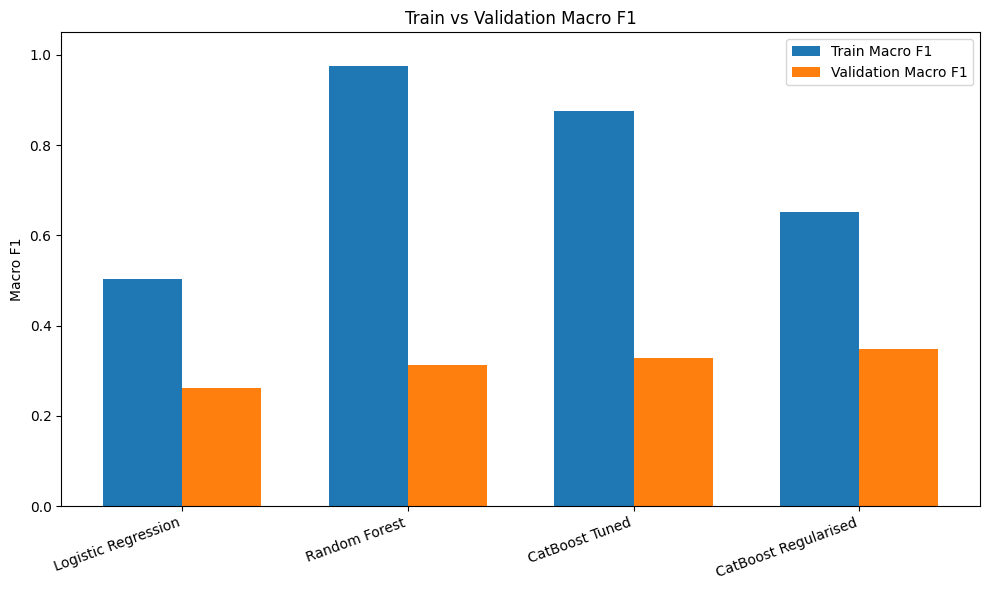

In [15]:
# -------------------------------------------------------------------
# Train vs Validation Macro F1
# -------------------------------------------------------------------

import matplotlib.pyplot as plt
import numpy as np

models = model_results["Model"]

train_scores = model_results["Train_Macro_F1"]
validation_scores = model_results["Validation_Macro_F1"]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    train_scores,
    width,
    label="Train Macro F1",
)

plt.bar(
    x + width / 2,
    validation_scores,
    width,
    label="Validation Macro F1",
)

plt.xticks(
    x,
    models,
    rotation=20,
    ha="right",
)

plt.ylabel("Macro F1")
plt.title("Train vs Validation Macro F1")
plt.ylim(0, 1.05)

plt.legend()
plt.tight_layout()
plt.show()

## Regularised Random Forest Search

The default Random Forest achieved the strongest validation Macro F1, but it completely fitted the training data.

A second experiment therefore constrains tree complexity and increases regularisation to determine whether similar validation performance can be preserved with improved generalisation.

In [16]:
# -------------------------------------------------------------------
# Regularised Random Forest Search
# -------------------------------------------------------------------

from sklearn.model_selection import RandomizedSearchCV

regularised_rf = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor,
        ),
        (
            "classifier",
            RandomForestClassifier(
                random_state=42,
                class_weight="balanced_subsample",
                n_jobs=-1,
            ),
        ),
    ]
)

rf_param_grid = {
    "classifier__n_estimators": [
        300,
        500,
        800,
        1200,
    ],
    "classifier__max_depth": [
        3,
        5,
        7,
        10,
        None,
    ],
    "classifier__min_samples_split": [
        2,
        5,
        10,
        15,
    ],
    "classifier__min_samples_leaf": [
        1,
        2,
        4,
        6,
        10,
    ],
    "classifier__max_features": [
        "sqrt",
        "log2",
        0.5,
    ],
}

rf_search = RandomizedSearchCV(
    estimator=regularised_rf,
    param_distributions=rf_param_grid,
    n_iter=40,
    scoring="f1_macro",
    cv=group_cv,
    random_state=42,
    n_jobs=-1,
    verbose=1,
    error_score="raise",
)

rf_search.fit(
    X_train_model,
    y_train,
    groups=train_groups,
)

print("REGULARISED RANDOM FOREST SEARCH COMPLETE")
print("-" * 70)

print(
    f"Best CV Macro F1: "
    f"{rf_search.best_score_:.4f}"
)

print()
print("Best Parameters:")
print(rf_search.best_params_)

Fitting 5 folds for each of 40 candidates, totalling 200 fits
REGULARISED RANDOM FOREST SEARCH COMPLETE
----------------------------------------------------------------------
Best CV Macro F1: 0.3922

Best Parameters:
{'classifier__n_estimators': 300, 'classifier__min_samples_split': 5, 'classifier__min_samples_leaf': 6, 'classifier__max_features': 0.5, 'classifier__max_depth': 7}


### Regularised Random Forest Generalisation Check

The best regularised Random Forest configuration is evaluated on both training and validation data.

This determines whether the stronger cross-validation result is accompanied by improved generalisation or whether the model still substantially overfits the training properties.

In [17]:
# -------------------------------------------------------------------
# Regularised Random Forest Generalisation Check
# -------------------------------------------------------------------

best_regularised_rf = rf_search.best_estimator_

# Predictions.
reg_rf_train_predictions = best_regularised_rf.predict(
    X_train_model
)

reg_rf_val_predictions = best_regularised_rf.predict(
    X_val_model
)

reg_rf_val_probabilities = best_regularised_rf.predict_proba(
    X_val_model
)

reg_rf_classes = best_regularised_rf.named_steps[
    "classifier"
].classes_

# ---------------------------------------------------------------
# Training metrics
# ---------------------------------------------------------------

reg_rf_train_accuracy = accuracy_score(
    y_train,
    reg_rf_train_predictions,
)

reg_rf_train_macro_f1 = f1_score(
    y_train,
    reg_rf_train_predictions,
    average="macro",
    zero_division=0,
)

# ---------------------------------------------------------------
# Validation metrics
# ---------------------------------------------------------------

reg_rf_val_accuracy = accuracy_score(
    y_val,
    reg_rf_val_predictions,
)

reg_rf_val_macro_f1 = f1_score(
    y_val,
    reg_rf_val_predictions,
    average="macro",
    zero_division=0,
)

reg_rf_val_weighted_f1 = f1_score(
    y_val,
    reg_rf_val_predictions,
    average="weighted",
    zero_division=0,
)

reg_rf_val_top2 = top_k_accuracy_score(
    y_val,
    reg_rf_val_probabilities,
    k=2,
    labels=reg_rf_classes,
)

reg_rf_val_top3 = top_k_accuracy_score(
    y_val,
    reg_rf_val_probabilities,
    k=3,
    labels=reg_rf_classes,
)

# ---------------------------------------------------------------
# Generalisation gaps
# ---------------------------------------------------------------

reg_rf_accuracy_gap = (
    reg_rf_train_accuracy
    - reg_rf_val_accuracy
)

reg_rf_macro_f1_gap = (
    reg_rf_train_macro_f1
    - reg_rf_val_macro_f1
)

# ---------------------------------------------------------------
# Add experiment to tracking table
# ---------------------------------------------------------------

new_result = pd.DataFrame(
    [
        {
            "Model": "Random Forest Regularised",
            "Train_Accuracy": reg_rf_train_accuracy,
            "Validation_Accuracy": reg_rf_val_accuracy,
            "Train_Macro_F1": reg_rf_train_macro_f1,
            "Validation_Macro_F1": reg_rf_val_macro_f1,
            "Validation_Weighted_F1": reg_rf_val_weighted_f1,
            "Validation_Top2": reg_rf_val_top2,
            "Validation_Top3": reg_rf_val_top3,
            "Accuracy_Gap": reg_rf_accuracy_gap,
            "Macro_F1_Gap": reg_rf_macro_f1_gap,
        }
    ]
)

model_results = pd.concat(
    [
        model_results,
        new_result,
    ],
    ignore_index=True,
)

print("REGULARISED RANDOM FOREST GENERALISATION CHECK")
print("-" * 70)

print("TRAIN")
print(f"Accuracy:       {reg_rf_train_accuracy:.4f}")
print(f"Macro F1:       {reg_rf_train_macro_f1:.4f}")

print()

print("VALIDATION")
print(f"Accuracy:       {reg_rf_val_accuracy:.4f}")
print(f"Macro F1:       {reg_rf_val_macro_f1:.4f}")
print(f"Weighted F1:    {reg_rf_val_weighted_f1:.4f}")
print(f"Top-2 Accuracy: {reg_rf_val_top2:.4f}")
print(f"Top-3 Accuracy: {reg_rf_val_top3:.4f}")

print()

print("GENERALISATION GAP")
print(f"Accuracy gap:   {reg_rf_accuracy_gap:.4f}")
print(f"Macro F1 gap:   {reg_rf_macro_f1_gap:.4f}")

REGULARISED RANDOM FOREST GENERALISATION CHECK
----------------------------------------------------------------------
TRAIN
Accuracy:       0.6190
Macro F1:       0.5779

VALIDATION
Accuracy:       0.4737
Macro F1:       0.3864
Weighted F1:    0.4168
Top-2 Accuracy: 0.7018
Top-3 Accuracy: 0.8596

GENERALISATION GAP
Accuracy gap:   0.1454
Macro F1 gap:   0.1915


### Model Comparison

All modelling experiments are compared using validation performance and the train-validation generalisation gap.

This comparison highlights the trade-off between predictive performance and overfitting across increasingly regularised models.

In [18]:
# -------------------------------------------------------------------
# Model Comparison
# -------------------------------------------------------------------

comparison_columns = [
    "Model",
    "Train_Macro_F1",
    "Validation_Macro_F1",
    "Macro_F1_Gap",
    "Validation_Accuracy",
    "Validation_Top2",
    "Validation_Top3",
]

model_comparison = (
    model_results[comparison_columns]
    .sort_values(
        by="Validation_Macro_F1",
        ascending=False,
    )
    .reset_index(drop=True)
)

print("MODEL COMPARISON")
print("-" * 110)

print(
    model_comparison
    .round(4)
    .to_string(index=False)
)

MODEL COMPARISON
--------------------------------------------------------------------------------------------------------------
                    Model  Train_Macro_F1  Validation_Macro_F1  Macro_F1_Gap  Validation_Accuracy  Validation_Top2  Validation_Top3
Random Forest Regularised          0.5779               0.3864        0.1915               0.4737           0.7018           0.8596
     CatBoost Regularised          0.6513               0.3487        0.3026               0.4737           0.7544           0.9298
           CatBoost Tuned          0.8746               0.3276        0.5470               0.4561           0.7193           0.9123
            Random Forest          0.9753               0.3130        0.6623               0.3860           0.6842           0.8421
      Logistic Regression          0.5029               0.2628        0.2401               0.3509           0.6491           0.8421


## Feature Importance

Feature importance is examined for the regularised Random Forest model to identify which household, AI-derived, property and customer signals contribute most strongly to the next-category recommendation.

The analysis is descriptive rather than causal: importance indicates that a feature is useful to the fitted model, but does not imply that the feature causes a customer to document a particular category next.

In [19]:
# -------------------------------------------------------------------
# Random Forest Feature Importance
# -------------------------------------------------------------------

# Retrieve the fitted preprocessing and classifier components.
fitted_preprocessor = best_regularised_rf.named_steps[
    "preprocessor"
]

fitted_rf = best_regularised_rf.named_steps[
    "classifier"
]

# Recover the transformed feature names after preprocessing.
feature_names = fitted_preprocessor.get_feature_names_out()

# Build a ranked feature-importance table.
feature_importance = pd.DataFrame(
    {
        "Feature": feature_names,
        "Importance": fitted_rf.feature_importances_,
    }
).sort_values(
    by="Importance",
    ascending=False,
).reset_index(drop=True)

print("TOP 25 RANDOM FOREST FEATURES")
print("-" * 100)

print(
    feature_importance
    .head(25)
    .round(4)
    .to_string(index=False)
)

TOP 25 RANDOM FOREST FEATURES
----------------------------------------------------------------------------------------------------
                                     Feature  Importance
         numerical__documented_count_CAT-001      0.2667
numerical__documented_replacement_cost_total      0.1388
           numerical__documented_value_total      0.1213
         numerical__documented_count_CAT-003      0.1049
         numerical__documented_count_CAT-005      0.0914
         numerical__documented_count_CAT-006      0.0853
        numerical__documented_category_count      0.0641
           numerical__documented_asset_count      0.0635
         numerical__documented_count_CAT-002      0.0301
             numerical__mean_evidence_rating      0.0296
         numerical__documented_count_CAT-004      0.0043
         numerical__documented_count_CAT-007      0.0000


### Validation Permutation Importance

Permutation importance is calculated on the validation partition to estimate how much predictive performance decreases when each feature is randomly disrupted.

Unlike tree-based impurity importance, this analysis evaluates feature usefulness directly on unseen properties and therefore provides a stronger indication of which variables contribute to generalisation.

In [20]:
# -------------------------------------------------------------------
# Validation Permutation Importance
# -------------------------------------------------------------------

from sklearn.inspection import permutation_importance

# Calculate importance directly on the validation partition.
permutation_result = permutation_importance(
    best_regularised_rf,
    X_val_model,
    y_val,
    scoring="f1_macro",
    n_repeats=20,
    random_state=42,
    n_jobs=-1,
)

permutation_features = pd.DataFrame(
    {
        "Feature": X_val_model.columns,
        "Importance_Mean": permutation_result.importances_mean,
        "Importance_Std": permutation_result.importances_std,
    }
).sort_values(
    by="Importance_Mean",
    ascending=False,
).reset_index(drop=True)

print("TOP 25 VALIDATION PERMUTATION IMPORTANCE")
print("-" * 100)

print(
    permutation_features
    .head(25)
    .round(4)
    .to_string(index=False)
)

TOP 25 VALIDATION PERMUTATION IMPORTANCE
----------------------------------------------------------------------------------------------------
                          Feature  Importance_Mean  Importance_Std
         documented_count_CAT-001           0.1710          0.0393
         documented_count_CAT-003           0.0556          0.0237
documented_replacement_cost_total           0.0489          0.0232
           documented_value_total           0.0415          0.0279
         documented_count_CAT-005           0.0248          0.0133
         documented_count_CAT-006           0.0078          0.0291
             mean_evidence_rating           0.0000          0.0000
         documented_count_CAT-004           0.0000          0.0000
         documented_count_CAT-007           0.0000          0.0000
           documented_asset_count          -0.0004          0.0164
         documented_count_CAT-002          -0.0024          0.0047
        documented_category_count          -0.0048    

## Final Holdout Evaluation By Recommendation Objective

The final models are selected using validation performance only.

The standard Random Forest is retained for the primary Top-1 recommendation, while the regularised Random Forest is retained for Top-2 and Top-3 ranked recommendations.

The untouched test partition is evaluated once to estimate final performance on unseen properties.

In [21]:
# -------------------------------------------------------------------
# Final Holdout Evaluation By Recommendation Objective
# -------------------------------------------------------------------

# Prepare untouched test predictors.
X_test_model = X_test.drop(
    columns=excluded_features,
    errors="ignore",
).copy()

# ---------------------------------------------------------------
# Top-1 Model: Standard Random Forest
# ---------------------------------------------------------------

top1_predictions = random_forest_model.predict(
    X_test_model
)

top1_accuracy = accuracy_score(
    y_test,
    top1_predictions,
)

top1_macro_f1 = f1_score(
    y_test,
    top1_predictions,
    average="macro",
    zero_division=0,
)

top1_weighted_f1 = f1_score(
    y_test,
    top1_predictions,
    average="weighted",
    zero_division=0,
)

# ---------------------------------------------------------------
# Top-2 / Top-3 Model: Regularised Random Forest
# ---------------------------------------------------------------

ranking_probabilities = best_regularised_rf.predict_proba(
    X_test_model
)

ranking_classes = best_regularised_rf.named_steps[
    "classifier"
].classes_

top2_accuracy = top_k_accuracy_score(
    y_test,
    ranking_probabilities,
    k=2,
    labels=ranking_classes,
)

top3_accuracy = top_k_accuracy_score(
    y_test,
    ranking_probabilities,
    k=3,
    labels=ranking_classes,
)

# ---------------------------------------------------------------
# Final results
# ---------------------------------------------------------------

print("FINAL HOLDOUT TEST RESULTS")
print("-" * 70)

print("TOP-1 MODEL — RANDOM FOREST")
print(f"Accuracy:    {top1_accuracy:.4f}")
print(f"Macro F1:    {top1_macro_f1:.4f}")
print(f"Weighted F1: {top1_weighted_f1:.4f}")

print()

print("RANKING MODEL — REGULARISED RANDOM FOREST")
print(f"Top-2 Accuracy: {top2_accuracy:.4f}")
print(f"Top-3 Accuracy: {top3_accuracy:.4f}")

FINAL HOLDOUT TEST RESULTS
----------------------------------------------------------------------
TOP-1 MODEL — RANDOM FOREST
Accuracy:    0.4576
Macro F1:    0.3452
Weighted F1: 0.4078

RANKING MODEL — REGULARISED RANDOM FOREST
Top-2 Accuracy: 0.6949
Top-3 Accuracy: 0.8814


## Final Per-Class Evaluation

The final Top-1 model is analysed by category to identify where recommendation performance is strongest and where minority categories remain difficult to predict.

These results are used for interpretation only. No further model tuning is performed using the holdout test set.

In [22]:
# -------------------------------------------------------------------
# Final Per-Class Evaluation
# -------------------------------------------------------------------

from sklearn.metrics import classification_report, confusion_matrix

# Classification metrics by target category.
print("FINAL TOP-1 CLASSIFICATION REPORT")
print("-" * 80)

print(
    classification_report(
        y_test,
        top1_predictions,
        digits=4,
        zero_division=0,
    )
)

# Confusion matrix.
confusion = pd.DataFrame(
    confusion_matrix(
        y_test,
        top1_predictions,
        labels=random_forest_model.classes_,
    ),
    index=random_forest_model.classes_,
    columns=random_forest_model.classes_,
)

print()
print("FINAL TOP-1 CONFUSION MATRIX")
print("-" * 80)

print(
    confusion.to_string()
)

FINAL TOP-1 CLASSIFICATION REPORT
--------------------------------------------------------------------------------
                              precision    recall  f1-score   support

                  Appliances     0.3636    0.4444    0.4000         9
                   Clothings     0.5000    0.2000    0.2857         5
                 Electronics     0.6000    0.8182    0.6923        11
                   Furniture     0.6000    0.5455    0.5714        11
Jewellery and Personal Items     0.0000    0.0000    0.0000        11
                 Other Items     0.3684    0.6364    0.4667        11
                    Vehicles     0.0000    0.0000    0.0000         1

                    accuracy                         0.4576        59
                   macro avg     0.3474    0.3778    0.3452        59
                weighted avg     0.3903    0.4576    0.4078        59


FINAL TOP-1 CONFUSION MATRIX
--------------------------------------------------------------------------------
 

## Modelling Conclusion

This notebook is one cell of the anonymisation hypothesis-test matrix: **source release, pure-record feature set (12 predictors)**. Only the documented-inventory predictors are used: the seven documented counts per category and five documented aggregates. The partitions are the shared customer-grouped split (315 / 57 / 59 rows, no customer or property shared between partitions) and the cross-validation folds use the customer labels shared by all cells. Results are saved to `results_validation.csv` and `results_holdout_test.csv`.

**Final holdout result (59 rows, evaluated once)**, with the full feature set of the same release (same partitions) for reference:

| Metric | Pure record (12) | Full (55) | Pure record minus full |
|---|---|---|---|
| Top-1 accuracy | 0.4576 | 0.4915 | -0.0339 (2 rows) |
| Top-1 Macro F1 | 0.3452 | 0.3683 | -0.0231 |
| Top-1 Weighted F1 | 0.4078 | 0.4348 | -0.0270 |
| Top-2 accuracy | 0.6949 | 0.7627 | -0.0678 (4 rows) |
| Top-3 accuracy | 0.8814 | 0.8814 | 0.0000 |

One test row is 1.7 percentage points. Twelve predictors give results within two to four test rows of the 55-predictor model, which suggests that most of the usable signal sits in the documented category counts, but a 59-row test set cannot confirm this. The ranking model was selected with `min_samples_split=5`, `min_samples_leaf=6` and `max_depth=7`, different from the settings selected in the other cells, so differences in Top-2 and Top-3 between feature sets are also affected by the ranking-model settings.

**Comparison with the regions release.** None of the 12 predictors differs between the source and the anonymised release, and the partitions and folds are the same, so this cell is expected to give the same results as the regions pure-record cell. It does: every holdout metric, every row of the validation table, the best cross-validation scores and the selected settings are identical. This is a consistency check of the pipeline; the two cells were run on two different computers.

**Validation comparison (source, pure record).**

| Model | Validation accuracy | Validation Macro F1 | Train-validation Macro F1 gap |
|---|---|---|---|
| Majority class | 0.2281 | 0.0619 | -0.0112 |
| Logistic Regression | 0.3509 | 0.2628 | 0.2401 |
| Random Forest | 0.3860 | 0.3130 | 0.6623 |
| CatBoost Tuned | 0.4561 | 0.3276 | 0.5470 |
| CatBoost Regularised | 0.4737 | 0.3487 | 0.3026 |
| Random Forest Regularised | 0.4737 | 0.3864 | 0.1915 |

All learned models beat the majority baseline. The regularised Random Forest has the highest validation Macro F1 (0.3864) and, unlike in the full and no-AI cells, is really regularised (train Macro F1 0.5779). The standard Random Forest and tuned CatBoost still overfit (gaps 0.66 and 0.55). Best cross-validation Macro F1 was 0.3909 (CatBoost tuned), 0.3720 (CatBoost regularised) and 0.3922 (Random Forest).

**Per-class behaviour on the holdout set.** Electronics is recalled in 9 of 11 cases, Other Items in 7 of 11, Furniture in 6 of 11 and Appliances in 4 of 9. Jewellery and Personal Items is never recalled (0 of 11), Clothings is recalled in 1 of 5 and the single Vehicles case is missed.

**Feature importance.** `documented_count_CAT-001` is again the dominant predictor (permutation importance 0.171), followed by `documented_count_CAT-003` (0.056), `documented_replacement_cost_total` (0.049) and `documented_value_total` (0.042). Standard deviations are large, so the ranking beyond the first predictor is uncertain.

**Scope of this cell.** The built-in AI-ablation section of the official notebook is not included: the AI features are already removed here.

**Limitations.** The table has 431 prediction states and the test partition 59 rows, so every estimate has wide uncertainty. Results come from a single customer-grouped split with seed 42.

## Save Final Models

The selected Top-1 and ranking models are persisted for reuse in inference and deployment workflows.

In [23]:
# -------------------------------------------------------------------
# Save Final Models
# -------------------------------------------------------------------

from pathlib import Path
import joblib

MODELS_DIR.mkdir(parents=True, exist_ok=True)

top1_model_path = MODELS_DIR / f"{MODEL_PREFIX}_top1.joblib"
ranking_model_path = MODELS_DIR / f"{MODEL_PREFIX}_ranking.joblib"

joblib.dump(
    random_forest_model,
    top1_model_path,
)

joblib.dump(
    best_regularised_rf,
    ranking_model_path,
)

print("FINAL MODELS SAVED")
print("-" * 60)
print(f"Top-1 model:   {top1_model_path}")
print(f"Ranking model: {ranking_model_path}")

FINAL MODELS SAVED
------------------------------------------------------------
Top-1 model:   ..\..\..\..\models\hypothesis_testing\source_pure_record_top1.joblib
Ranking model: ..\..\..\..\models\hypothesis_testing\source_pure_record_ranking.joblib


## Save Run Results

The validation comparison (including the majority-class baseline), the final holdout results and the three partitions are saved so that the experiment cells can be compared and the paper tables filled without re-running the models.

Top-2 and Top-3 accuracy are not reported for the majority-class baseline because its one-hot probabilities make those scores tie-dependent.

In [24]:
# -------------------------------------------------------------------
# Save Run Results
# -------------------------------------------------------------------

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Majority-class baseline, added to the validation comparison table.
baseline_train_predictions = baseline_model.predict(X_train)

baseline_row = pd.DataFrame(
    [
        {
            "Model": "Majority Class",
            "Train_Accuracy": accuracy_score(
                y_train,
                baseline_train_predictions,
            ),
            "Validation_Accuracy": baseline_accuracy,
            "Train_Macro_F1": f1_score(
                y_train,
                baseline_train_predictions,
                average="macro",
                zero_division=0,
            ),
            "Validation_Macro_F1": baseline_macro_f1,
            "Validation_Weighted_F1": baseline_weighted_f1,
        }
    ]
)

results_validation = pd.concat(
    [
        baseline_row,
        model_results.drop(columns=["Accuracy_Gap", "Macro_F1_Gap"]),
    ],
    ignore_index=True,
)

results_validation["Accuracy_Gap"] = (
    results_validation["Train_Accuracy"]
    - results_validation["Validation_Accuracy"]
)

results_validation["Macro_F1_Gap"] = (
    results_validation["Train_Macro_F1"]
    - results_validation["Validation_Macro_F1"]
)

results_validation.insert(0, "Feature_Set", FEATURE_SET)
results_validation.insert(0, "Dataset", DATASET)

# Final holdout results.
results_holdout_test = pd.DataFrame(
    [
        {
            "Dataset": DATASET,
            "Feature_Set": FEATURE_SET,
            "Predictors": X_train_model.shape[1],
            "Test_Rows": len(X_test),
            "Top1_Accuracy": top1_accuracy,
            "Top1_Macro_F1": top1_macro_f1,
            "Top1_Weighted_F1": top1_weighted_f1,
            "Top2_Accuracy": top2_accuracy,
            "Top3_Accuracy": top3_accuracy,
        }
    ]
)

results_validation.to_csv(
    OUTPUT_DIR / "results_validation.csv",
    index=False,
)

results_holdout_test.to_csv(
    OUTPUT_DIR / "results_holdout_test.csv",
    index=False,
)

# Partitions used by this run.
model_state.iloc[train_idx].to_parquet(OUTPUT_DIR / "train_df.parquet", index=False)
model_state.iloc[val_idx].to_parquet(OUTPUT_DIR / "val_df.parquet", index=False)
model_state.iloc[test_idx].to_parquet(OUTPUT_DIR / "test_df.parquet", index=False)

print("RUN RESULTS SAVED")
print("-" * 60)
print(f"Folder: {OUTPUT_DIR}")
print()
print(results_validation.round(4).to_string(index=False))
print()
print(results_holdout_test.round(4).to_string(index=False))

RUN RESULTS SAVED
------------------------------------------------------------
Folder: ..\..\..\..\data\processed\hypothesis_testing\source_dataset\03_pure_record

       Dataset    Feature_Set                     Model  Train_Accuracy  Validation_Accuracy  Train_Macro_F1  Validation_Macro_F1  Validation_Weighted_F1  Validation_Top2  Validation_Top3  Accuracy_Gap  Macro_F1_Gap
source_dataset 03_pure_record            Majority Class          0.2159               0.2281          0.0507               0.0619                  0.0847              NaN              NaN       -0.0122       -0.0112
source_dataset 03_pure_record       Logistic Regression          0.5651               0.3509          0.5029               0.2628                  0.2934           0.6491           0.8421        0.2142        0.2401
source_dataset 03_pure_record             Random Forest          0.9714               0.3860          0.9753               0.3130                  0.3709           0.6842           0.8421 